## Author's Note

If you found this notebook helpful, please consider upvoting it — your support motivates me to keep improving and sharing better work with the community. Suggestions and feedback are always welcome!

### Thought: Don't worry about failure, you only have to be right once 😊😊

![Instagram EDA Banner](https://raw.githubusercontent.com/Aryan-Kaisth/kaggle_assets/main/assets/insta%20data%20eda.jpg)

📌 **Reader’s Guide**

This notebook provides a beginner-friendly, end-to-end exploratory data analysis (EDA) of a Social Media User Activity dataset. The objective is to guide readers step by step through the analysis in a clear, structured, and approachable manner. Each section explains not only *what* is being done, but also *why* it matters, helping newcomers build intuition about data exploration, visualization, and interpretation. By the end of the notebook, readers should feel more confident in performing their own EDA and understanding how to extract insights from a dataset.

In [1]:
# Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

In [2]:
# Reading data from source
df = pd.read_csv('/kaggle/input/social-media-user-activity-dataset/instagram_usage_lifestyle.csv')

In [3]:
# Preview of data
df.head(5)

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,diet_quality,smoking,alcohol_frequency,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,books_read_per_year,volunteer_hours_per_month,travel_frequency_per_year,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,uses_premium_features,notification_response_rate,account_creation_year,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,No,7.2,7.7,Good,No,Rarely,3,8,20.8,148,86,8107,49.9,3,4,7,4.3,0,5.0,1,3,42,28,28,5,12,12,4,1,2,1,1,2,374,647,No,0.34,2015,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,10.9,8.6,Very poor,No,Rarely,1,1,23.5,133,84,8059,15.6,0,5,10,4.7,2,74.0,5,3,78,54,68,15,18,10,11,1,31,19,16,19,2585,3511,No,0.56,2018,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,No,5.0,6.7,Good,No,Rarely,4,10,28.6,135,88,7872,31.8,4,5,14,1.5,2,5.0,1,7,29,26,25,6,12,13,4,0,3,1,1,1,3414,6761,No,0.73,2011,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,10.6,6.5,Poor,Yes,Never,18,1,22.5,105,73,7801,43.4,2,3,13,3.3,4,233.0,9,5,241,109,132,36,31,32,33,3,108,64,52,64,617,1193,No,0.73,2019,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,No,7.7,6.8,Average,No,Never,19,1,28.1,146,90,8005,50.2,2,2,12,4.5,3,184.0,14,5,146,113,103,36,29,37,20,5,78,55,22,55,1157,1072,Yes,0.65,2017,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [4]:
# Shape of data
df.shape

(1547896, 58)

In [5]:
# Datatypes of features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [6]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# Check for null instances
df.isna().sum().sum()

np.int64(0)

In [8]:
# Summary of data for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,1547896.0,773948.500000,446839.230477,1.00,386974.75,773948.5,1160922.25,1547896.00
age,1547896.0,38.985440,15.294528,13.00,26.00,39.0,52.00,65.00
exercise_hours_per_week,1547896.0,7.143480,3.994556,0.00,4.00,6.6,9.70,24.10
sleep_hours_per_night,1547896.0,6.999384,1.097098,3.00,6.30,7.0,7.70,10.00
perceived_stress_score,1547896.0,19.987738,11.832578,0.00,10.00,20.0,30.00,40.00
self_reported_happiness,1547896.0,5.499804,2.871232,1.00,3.00,5.0,8.00,10.00
body_mass_index,1547896.0,25.000837,3.976188,15.00,22.30,25.0,27.70,45.00
blood_pressure_systolic,1547896.0,124.491714,20.206989,90.00,107.00,124.0,142.00,159.00
blood_pressure_diastolic,1547896.0,79.500074,11.548740,60.00,70.00,79.0,90.00,99.00
daily_steps_count,1547896.0,8000.104562,89.397615,7566.00,7940.00,8000.0,8060.00,8473.00


In [9]:
# Summary of data for numerical features
df.describe(include='O').T

,count,unique,top,freq
app_name,1547896,1,Instagram,1547896
gender,1547896,4,Male,743169
country,1547896,10,United States,386829
urban_rural,1547896,3,Urban,850754
income_level,1547896,5,Middle,465037
employment_status,1547896,6,Full-time employed,695383
education_level,1547896,6,Bachelor’s,541083
relationship_status,1547896,5,Single,619236
has_children,1547896,2,No,1115158
diet_quality,1547896,5,Average,543910


In [10]:
# Convert the 'last_login_date' column to datetime format for time-based analysis

df['last_login_date'] = pd.to_datetime(df['last_login_date'])
df['account_creation_year'] = pd.to_datetime(df['account_creation_year'], format='%Y')

In [11]:
# Storing columns into their respective nature

cat_cols = df.select_dtypes('O').columns.to_list()
num_cols = df.select_dtypes([int, float]).columns.to_list()
print(f'Categorical features: {cat_cols}')
print(f'Total Categorical features: {len(cat_cols)}')
print('='*110)
print(f'Numerical features: {num_cols}')
print(f'Total Numerical features: {len(num_cols)}')

Categorical features: ['app_name', 'gender', 'country', 'urban_rural', 'income_level', 'employment_status', 'education_level', 'relationship_status', 'has_children', 'diet_quality', 'smoking', 'alcohol_frequency', 'uses_premium_features', 'content_type_preference', 'preferred_content_theme', 'privacy_setting_level', 'two_factor_auth_enabled', 'biometric_login_used', 'subscription_status']
Total Categorical features: 19
Numerical features: ['user_id', 'age', 'exercise_hours_per_week', 'sleep_hours_per_night', 'perceived_stress_score', 'self_reported_happiness', 'body_mass_index', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'daily_steps_count', 'weekly_work_hours', 'hobbies_count', 'social_events_per_month', 'books_read_per_year', 'volunteer_hours_per_month', 'travel_frequency_per_year', 'daily_active_minutes_instagram', 'sessions_per_day', 'posts_created_per_week', 'reels_watched_per_day', 'stories_viewed_per_day', 'likes_given_per_day', 'comments_written_per_day', 'dms_sent_

# Univariate Analysis
---

## Categirical Features Analysis

In [12]:
df.loc[:, cat_cols]

,app_name,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,uses_premium_features,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,subscription_status
0,Instagram,Female,India,Rural,High,Retired,Bachelor’s,Single,No,Good,No,Rarely,No,Mixed,Tech,Private,Yes,No,Free
1,Instagram,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,Very poor,No,Rarely,No,Photos,Fashion,Public,No,No,Free
2,Instagram,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,No,Good,No,Rarely,No,Mixed,Other,Public,Yes,Yes,Free
3,Instagram,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,Never,No,Stories,Tech,Private,No,No,Free
4,Instagram,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,No,Average,No,Never,Yes,Videos,Food,Public,Yes,No,Free
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,Instagram,Female,United States,Suburban,High,Full-time employed,Master’s,Widowed,No,Good,No,Weekly,No,Videos,Other,Friends only,Yes,Yes,Free
1547892,Instagram,Male,United States,Urban,Lower-middle,Full-time employed,Master’s,Divorced,No,Excellent,No,Never,No,Photos,Art,Private,No,No,Premium
1547893,Instagram,Male,Canada,Urban,Low,Full-time employed,Master’s,Single,No,Average,No,Weekly,No,Live,Other,Private,Yes,Yes,Free
1547894,Instagram,Female,Other,Urban,Low,Student,Bachelor’s,Single,No,Poor,No,Never,No,Live,Tech,Private,Yes,No,Free


In [13]:
df.app_name.unique()

array(['Instagram'], dtype=object)

In [14]:
# Remove app_name from categorical features
cat_cols.remove('app_name')

📌 app_name is constant

The app_name column contains the same value (“Instagram”) for every record. Since it doesn’t vary across the dataset, it doesn’t add any useful information for the analysis.

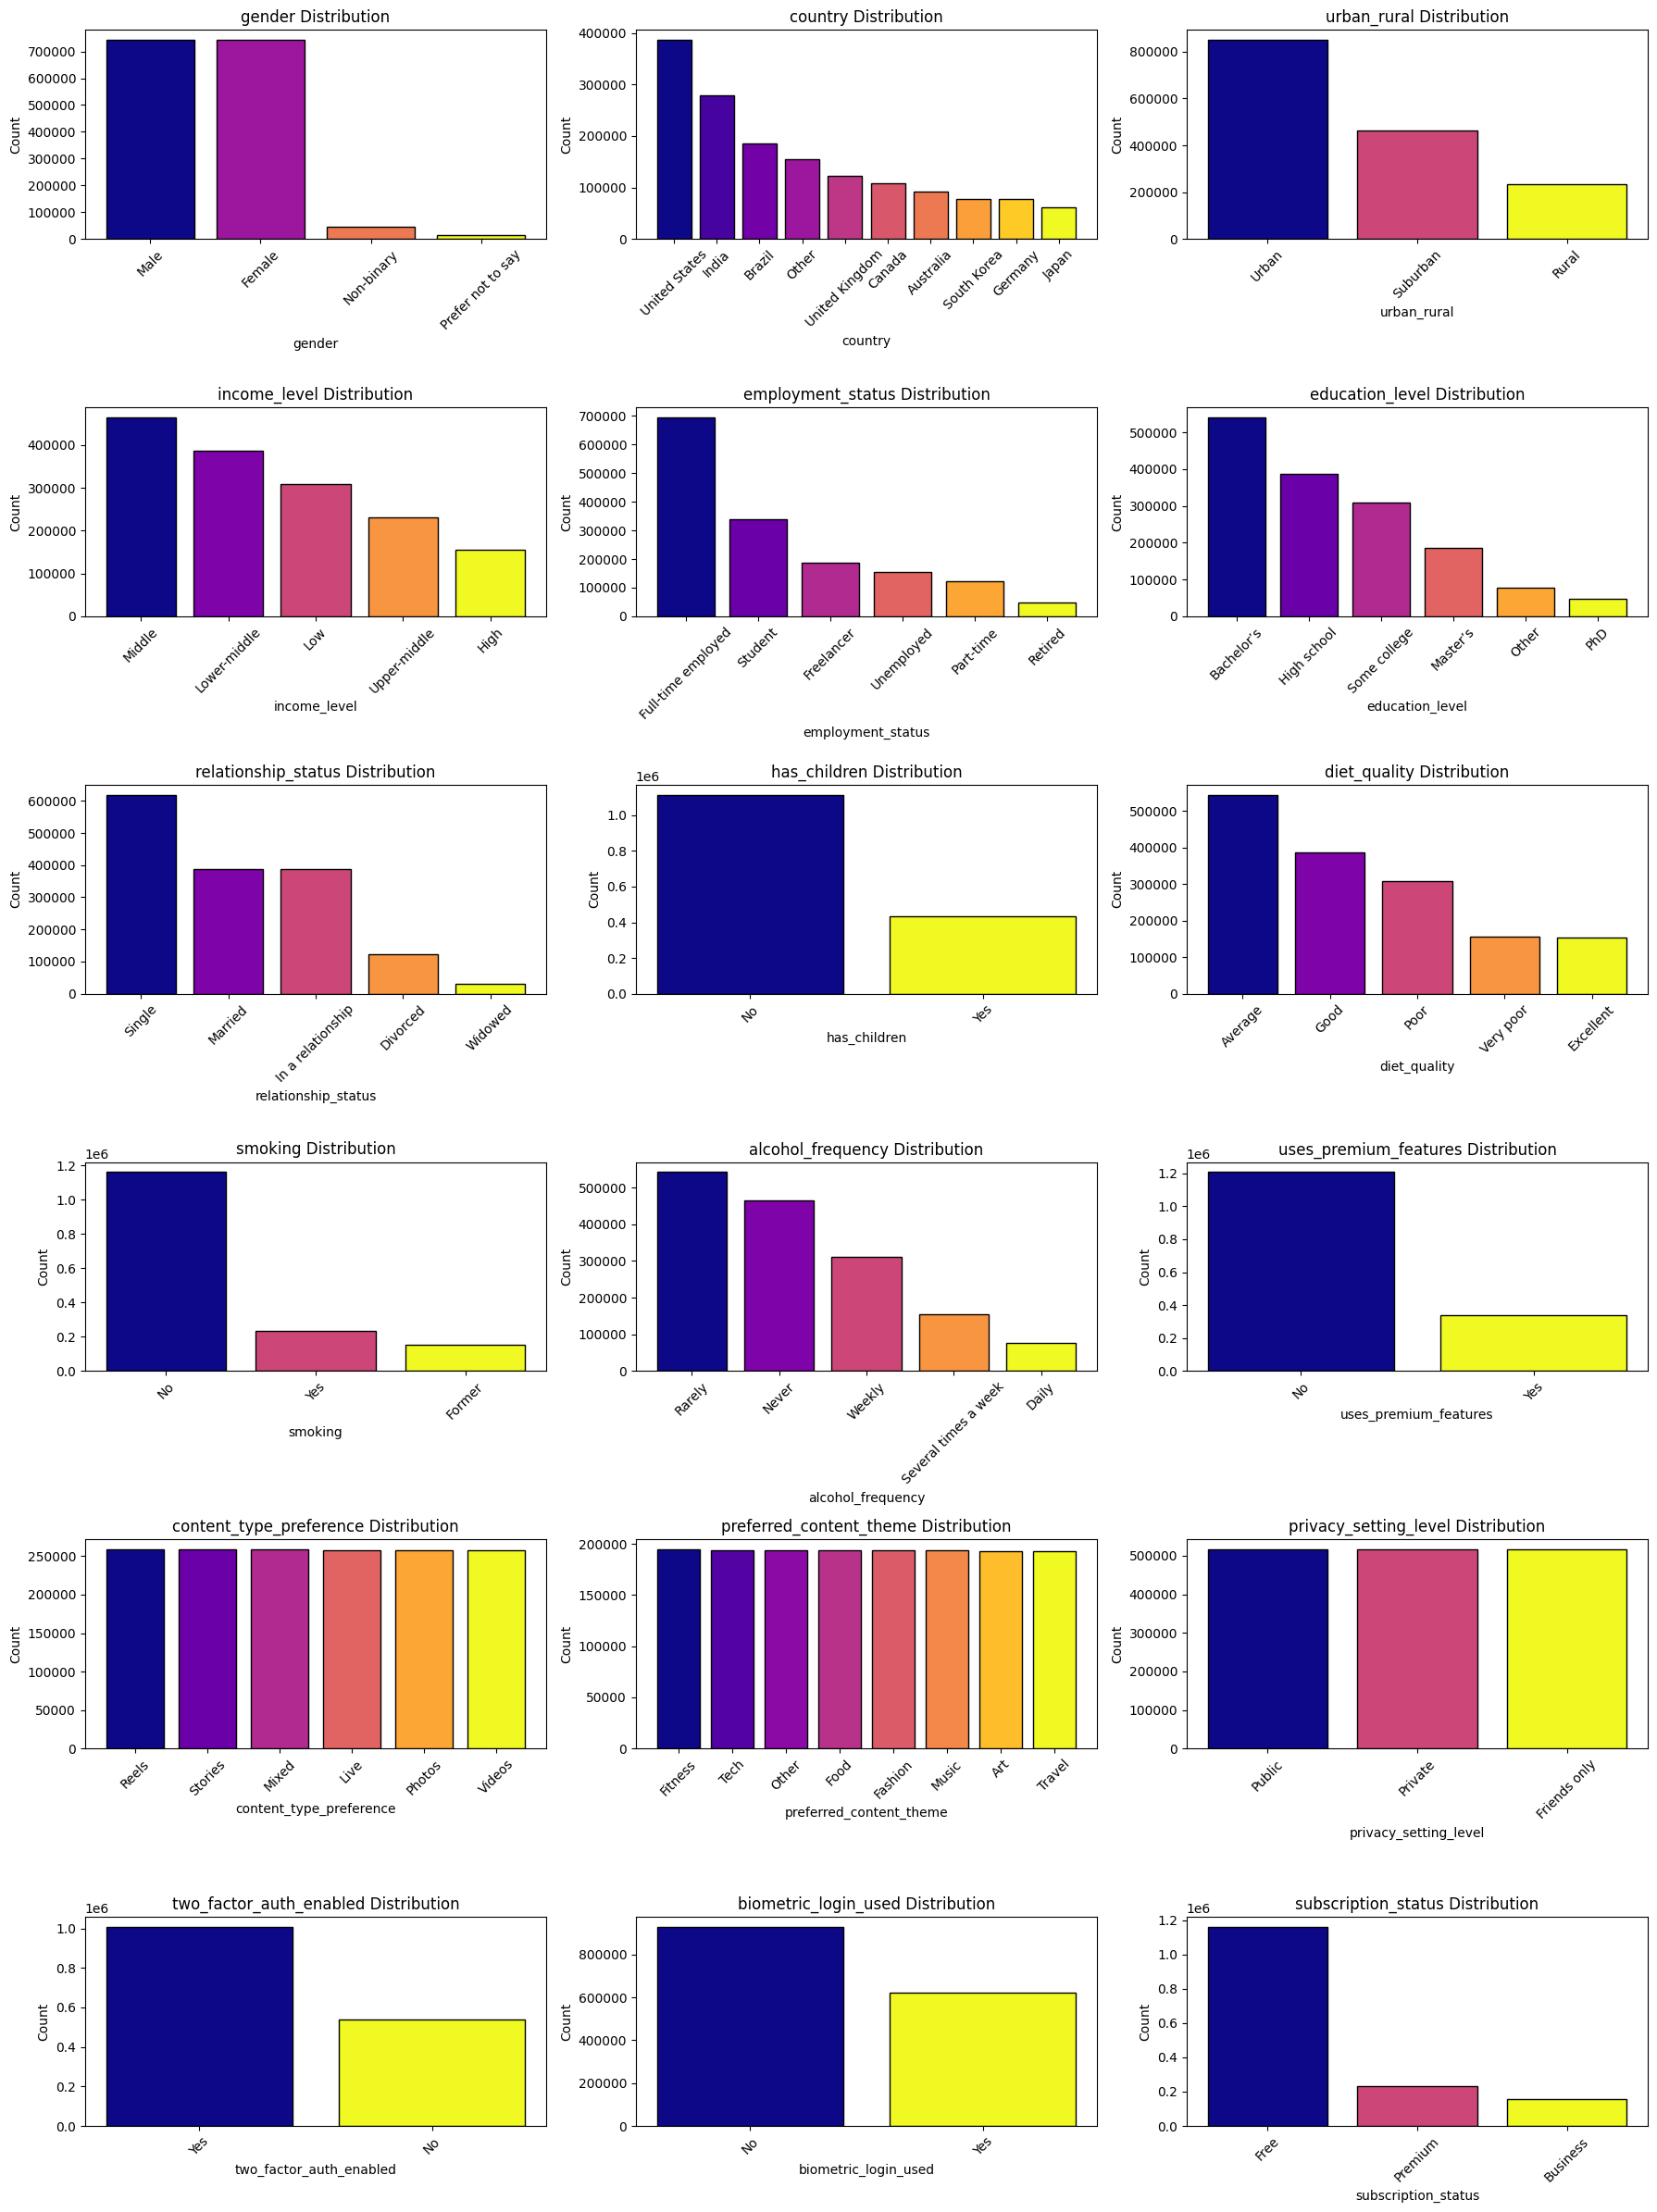

In [15]:
# Let's visualize the countplot of categorical features
n = len(cat_cols)
cols = 3  # number of subplot columns
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    colors = plt.cm.plasma(np.linspace(0, 1, len(vc)))

    axes[i].bar(
        vc.index,
        vc.values,
        color=colors,
        edgecolor='black'
    )

    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

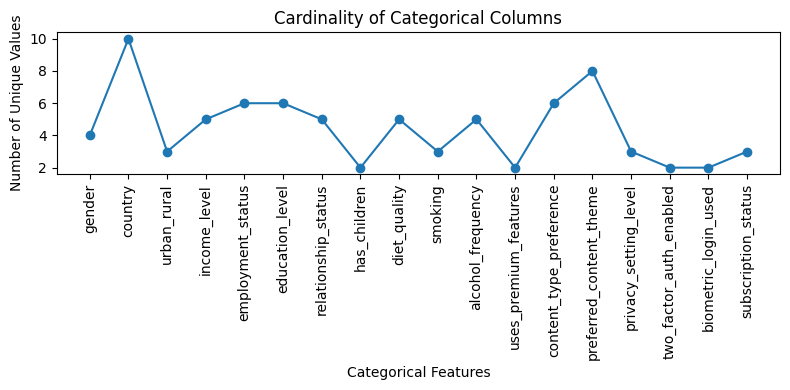

In [16]:
# Cardinality of categorical columns as a pandas Series
cardinality = df[cat_cols].nunique()

plt.figure(figsize=(8, 4))
plt.plot(cardinality.index, cardinality.values, marker='o')

plt.title('Cardinality of Categorical Columns')
plt.xlabel('Categorical Features')
plt.ylabel('Number of Unique Values')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Hypothesis Testing: Chi2 goodness-of-fit test

On looking at the count plots, these three features — content_type_preference, preferred_content_theme, and privacy_setting_level — appear to follow a roughly uniform pattern, so a chi-square goodness-of-fit test is performed to check whether their observed distributions significantly deviate from uniformity.

In [17]:
# Features to test
features = [
    'content_type_preference',
    'preferred_content_theme',
    'privacy_setting_level'
]

alpha = 0.05  # significance level

for col in features:
    obs = df[col].value_counts().sort_index()
    expected = [obs.sum() / len(obs)] * len(obs)

    chi2_stat, p_value = stats.chisquare(f_obs=obs, f_exp=expected)

    print("\n" + "="*55)
    print(f"Chi-square Goodness-of-Fit Test for: {col}")
    print("="*55)
    print("H0: The distribution is uniform.")
    print("H1: The distribution is not uniform.\n")

    print(f"Chi-square statistic : {chi2_stat:.3f}")
    print(f"P-value              : {p_value:.5f}")
    print(f"Significance level   : {alpha}\n")

    if p_value < alpha:
        print("Decision   : Reject H0")
        print("Inference  : The distribution significantly deviates from uniformity.")
    else:
        print("Decision   : Fail to reject H0")
        print("Inference  : No significant deviation from uniformity detected.")



Chi-square Goodness-of-Fit Test for: content_type_preference
H0: The distribution is uniform.
H1: The distribution is not uniform.

Chi-square statistic : 6.079
P-value              : 0.29857
Significance level   : 0.05

Decision   : Fail to reject H0
Inference  : No significant deviation from uniformity detected.

Chi-square Goodness-of-Fit Test for: preferred_content_theme
H0: The distribution is uniform.
H1: The distribution is not uniform.

Chi-square statistic : 12.160
P-value              : 0.09542
Significance level   : 0.05

Decision   : Fail to reject H0
Inference  : No significant deviation from uniformity detected.

Chi-square Goodness-of-Fit Test for: privacy_setting_level
H0: The distribution is uniform.
H1: The distribution is not uniform.

Chi-square statistic : 0.212
P-value              : 0.89962
Significance level   : 0.05

Decision   : Fail to reject H0
Inference  : No significant deviation from uniformity detected.


Based on the test results, the initial assumption appears to hold, suggesting that these three features follow a roughly uniform distribution.

## Numerical Features Analysis

In [18]:
df.loc[:, num_cols]

,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,books_read_per_year,volunteer_hours_per_month,travel_frequency_per_year,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,average_session_length_minutes,linked_accounts_count,user_engagement_score
0,1,51,7.2,7.7,3,8,20.8,148,86,8107,49.9,3,4,7,4.3,0,5.0,1,3,42,28,28,5,12,12,4,1,2,1,1,2,374,647,0.34,5.0,0,7.83
1,2,64,10.9,8.6,1,1,23.5,133,84,8059,15.6,0,5,10,4.7,2,74.0,5,3,78,54,68,15,18,10,11,1,31,19,16,19,2585,3511,0.56,14.8,3,1.43
2,3,41,5.0,6.7,4,10,28.6,135,88,7872,31.8,4,5,14,1.5,2,5.0,1,7,29,26,25,6,12,13,4,0,3,1,1,1,3414,6761,0.73,5.0,1,9.67
3,4,27,10.6,6.5,18,1,22.5,105,73,7801,43.4,2,3,13,3.3,4,233.0,9,5,241,109,132,36,31,32,33,3,108,64,52,64,617,1193,0.73,25.9,1,0.94
4,5,55,7.7,6.8,19,1,28.1,146,90,8005,50.2,2,2,12,4.5,3,184.0,14,5,146,113,103,36,29,37,20,5,78,55,22,55,1157,1072,0.65,13.1,0,1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,61,4.0,8.5,25,7,27.4,106,96,7863,38.0,3,6,8,2.1,6,190.0,12,6,156,111,125,21,35,26,23,4,104,46,33,65,1265,1012,0.48,15.8,4,0.97
1547892,1547893,42,3.1,6.1,8,7,24.2,95,71,7978,41.3,4,3,13,11.7,4,76.0,2,6,88,61,60,12,11,20,11,7,44,9,11,26,1312,1348,0.14,38.0,1,1.32
1547893,1547894,32,4.4,6.4,4,1,20.8,97,65,7898,48.5,4,3,9,1.7,4,159.0,5,4,156,91,92,29,29,23,16,5,76,19,33,48,1968,1891,0.99,31.8,5,1.01
1547894,1547895,14,14.4,6.5,28,7,31.1,97,96,7947,45.1,2,4,10,9.1,5,283.0,12,13,280,149,179,48,51,33,39,7,115,48,30,107,3932,4775,0.92,23.6,3,1.11


In [19]:
# Separate numeric columns into discrete (integer-based) and continuous (float-based) variables
discrete_cols = df.select_dtypes(include='int').columns.to_list()
continuous_cols = df.select_dtypes(include='float').columns.to_list()

discrete_cols.remove('user_id')

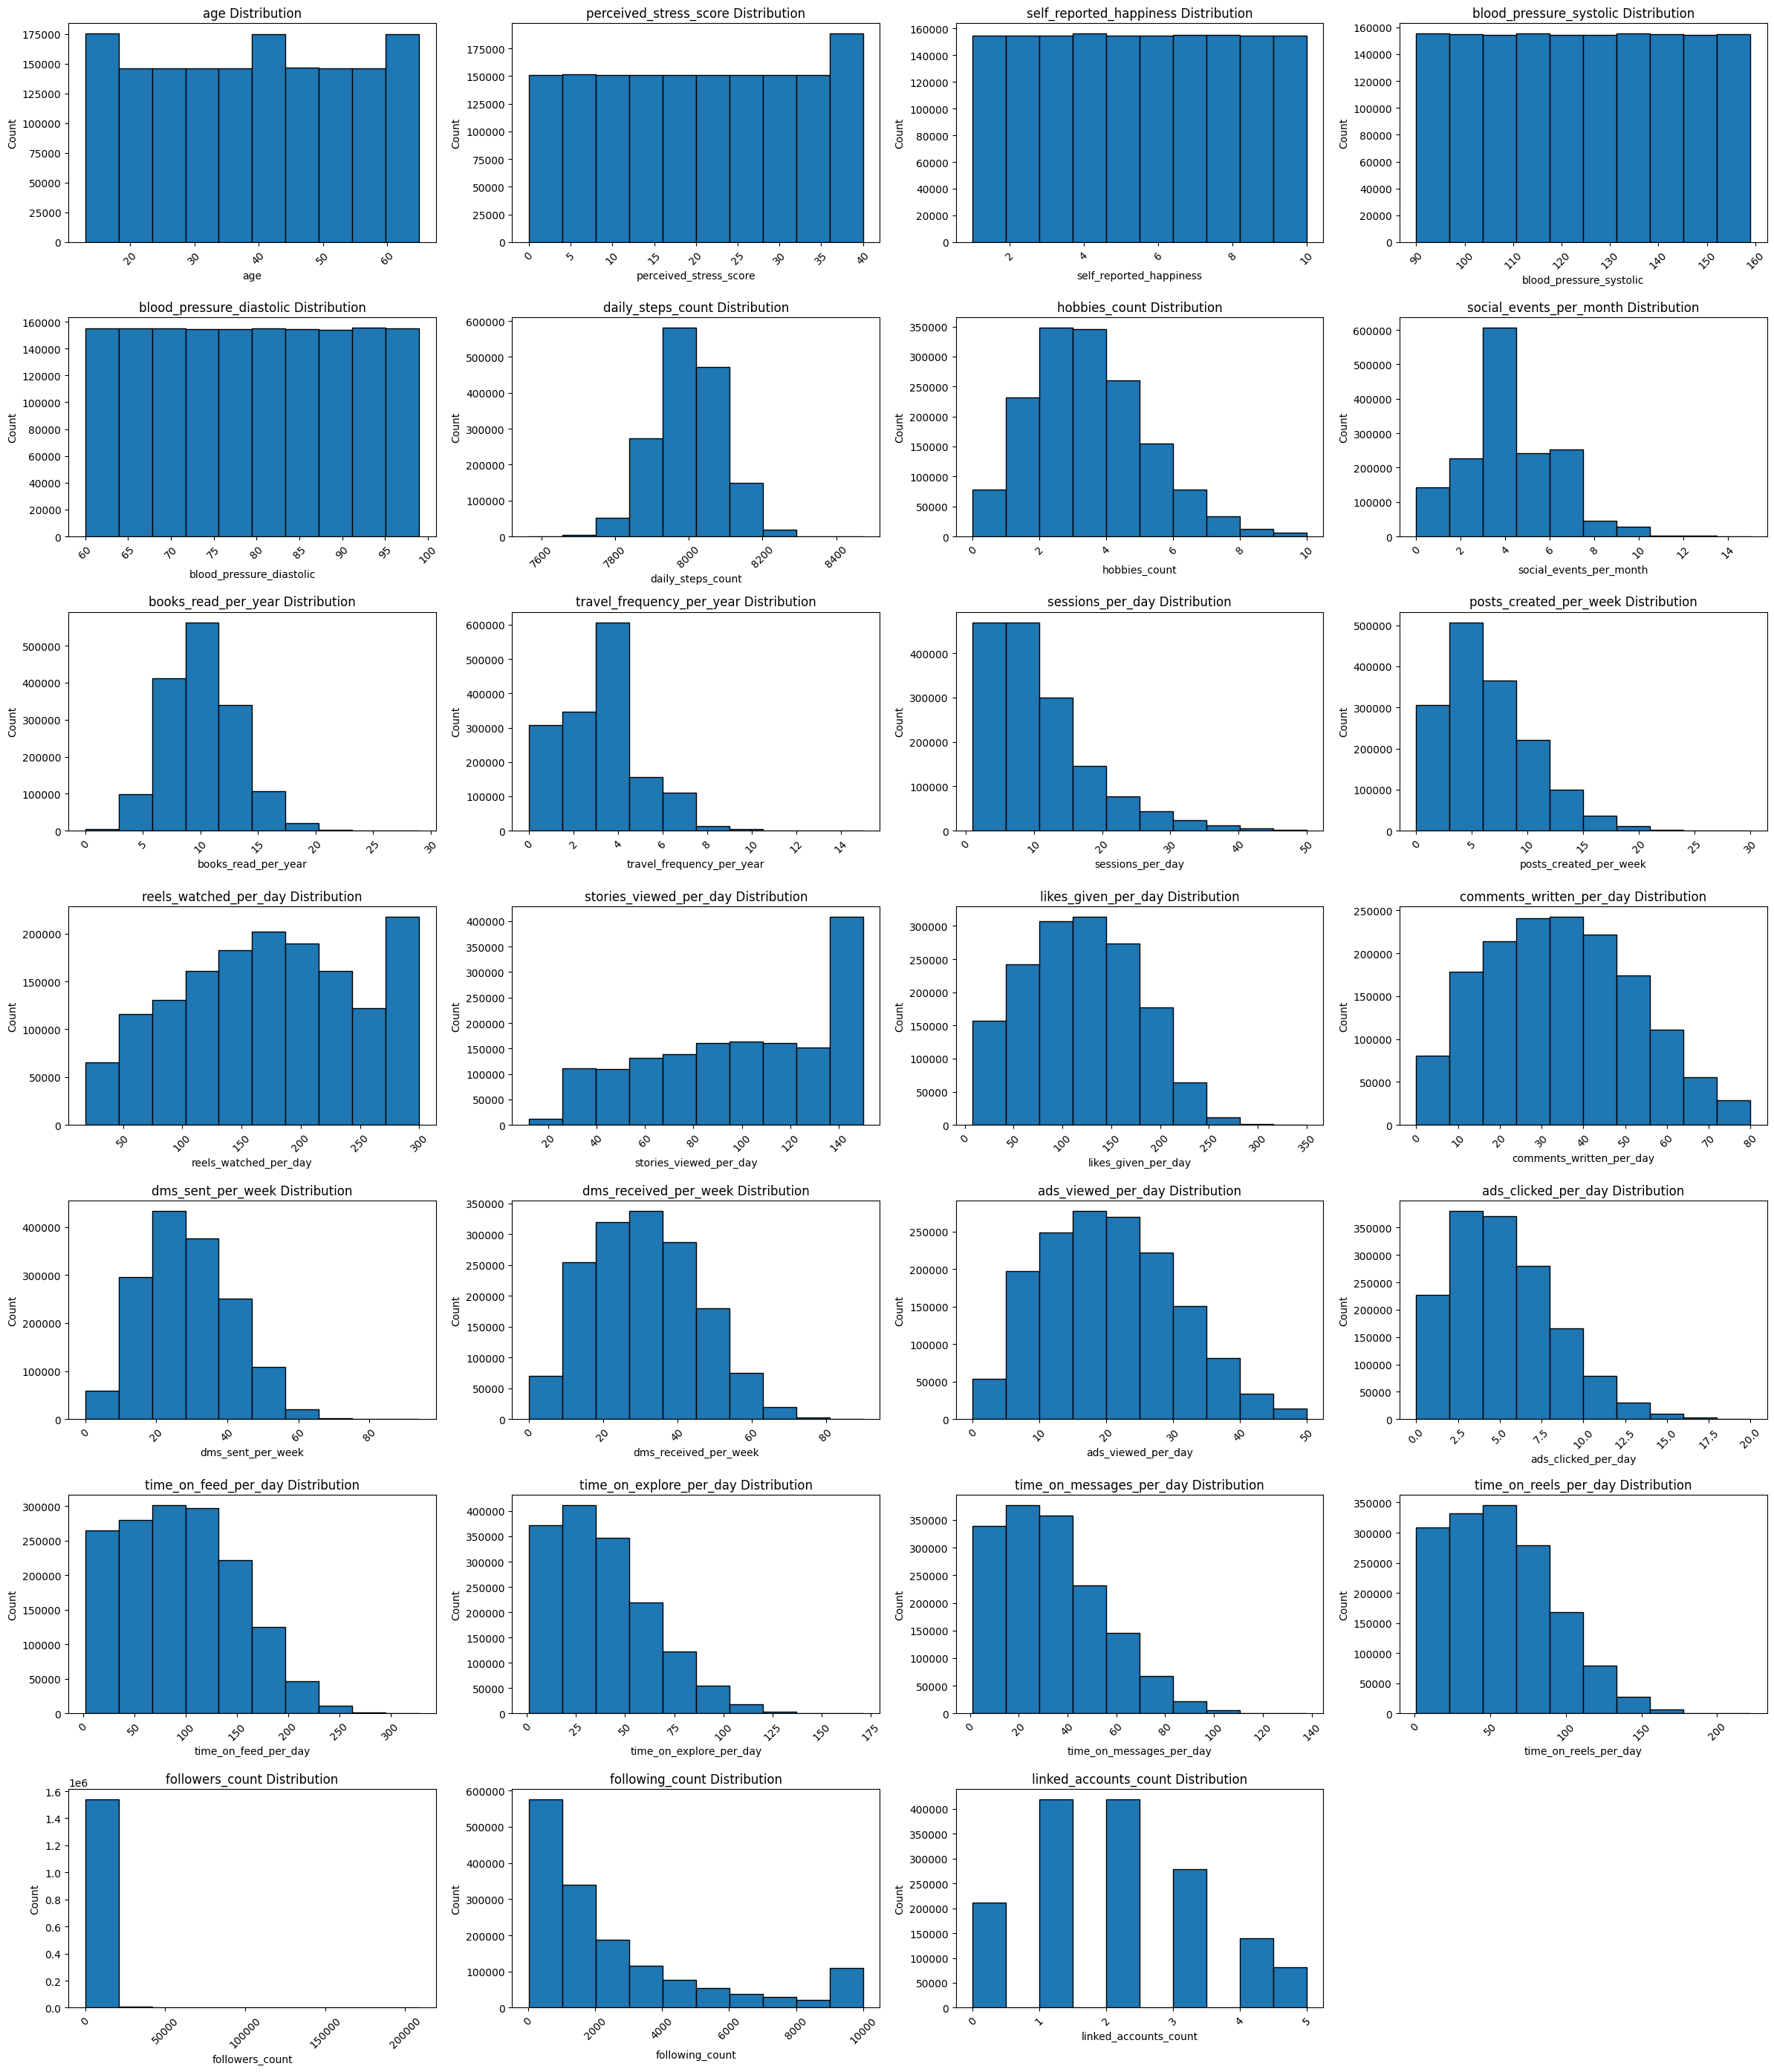

In [20]:
n = len(discrete_cols)
cols = 4  # number of subplot columns
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    axes[i].hist(
        df[col],
        edgecolor='black',
    )

    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

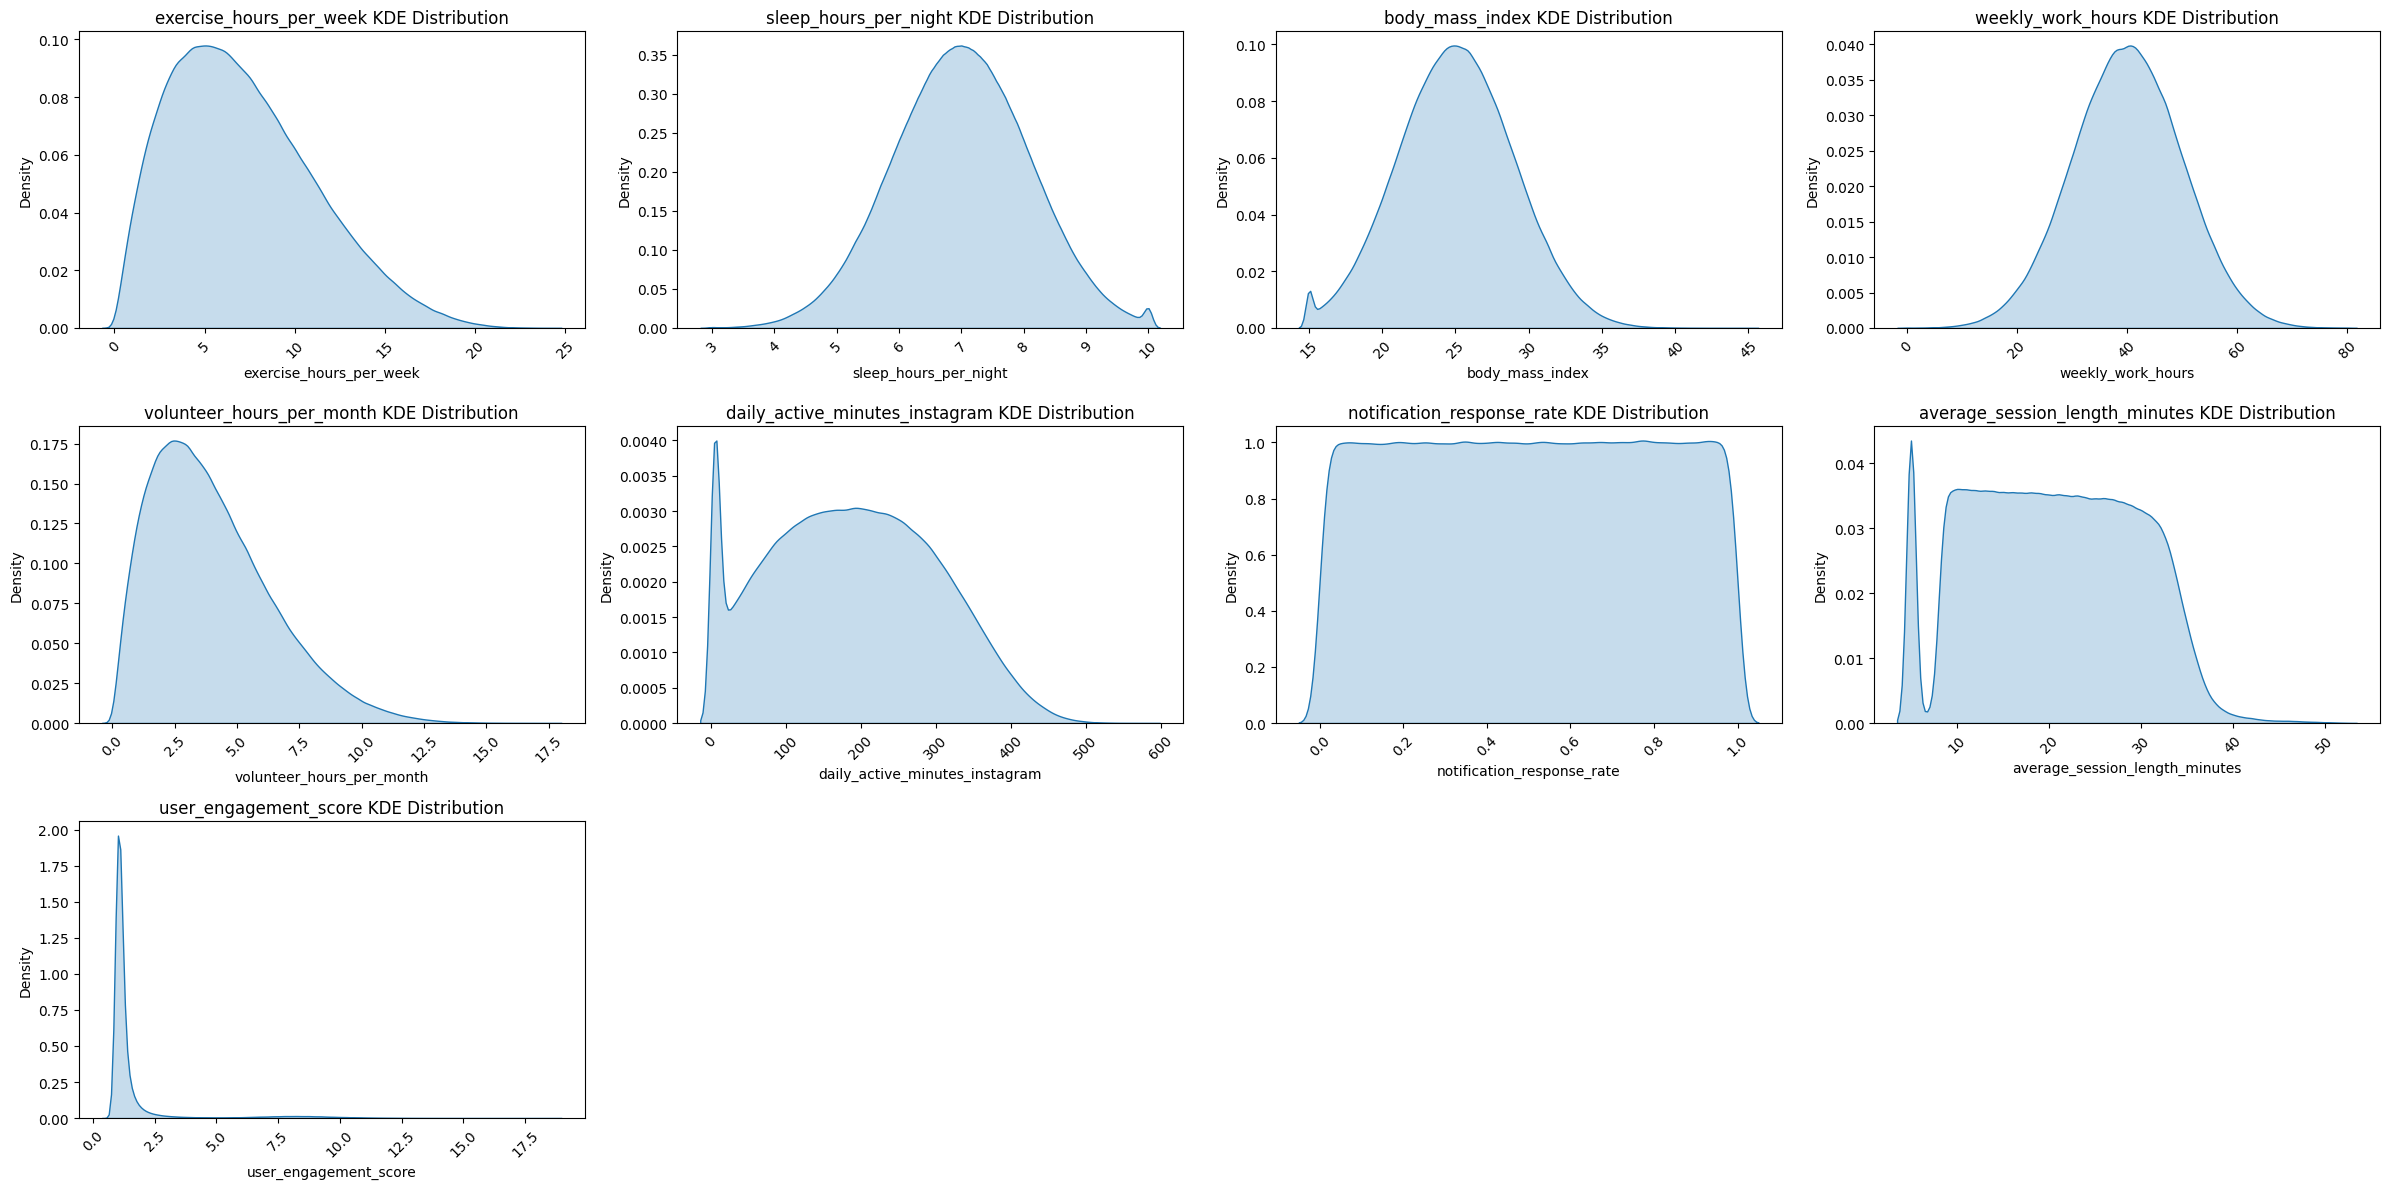

In [21]:
n = len(continuous_cols)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.kdeplot(
        x=df[col],
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} KDE Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


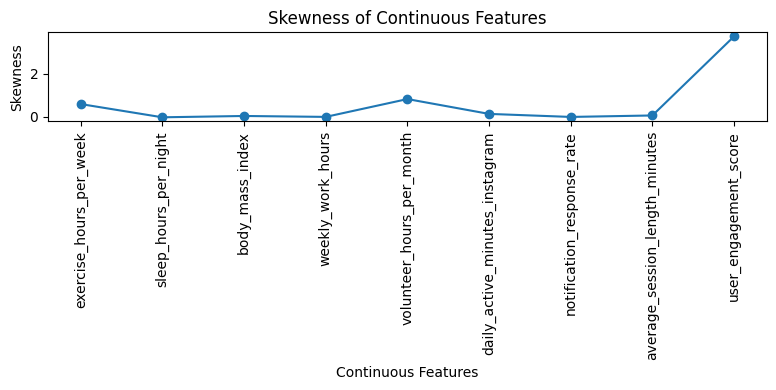

In [22]:
# Skewness of Continuous Features
skew = df[continuous_cols].skew()

plt.figure(figsize=(8, 4))
plt.plot(skew.index, skew.values, marker='o')

plt.title('Skewness of Continuous Features')
plt.xlabel('Continuous Features')
plt.ylabel('Skewness')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [23]:
desc_stats_df = pd.DataFrame(
    {
        'skewness': [df[col].skew() for col in continuous_cols],
        'kurtosis': [df[col].kurt() for col in continuous_cols]
        
    }
)

desc_stats_df

,skewness,kurtosis
0,0.597360,-0.117144
1,-0.018676,-0.083789
2,0.043034,-0.120427
3,0.000338,-0.003908
4,0.830432,0.491154
5,0.139595,-0.788594
6,-0.001539,-1.199845
7,0.066951,-0.865561
8,3.747916,13.801053


📌 What is Q-Q plot?

A Q–Q plot compares the distribution of my dataset with a theoretical normal distribution by plotting their quantiles against each other. If the points roughly fall along a straight diagonal line, it suggests that the data is approximately normally distributed. However, if the points curve away or show strong deviations from the line, it indicates that the feature may be skewed or not normally distributed.

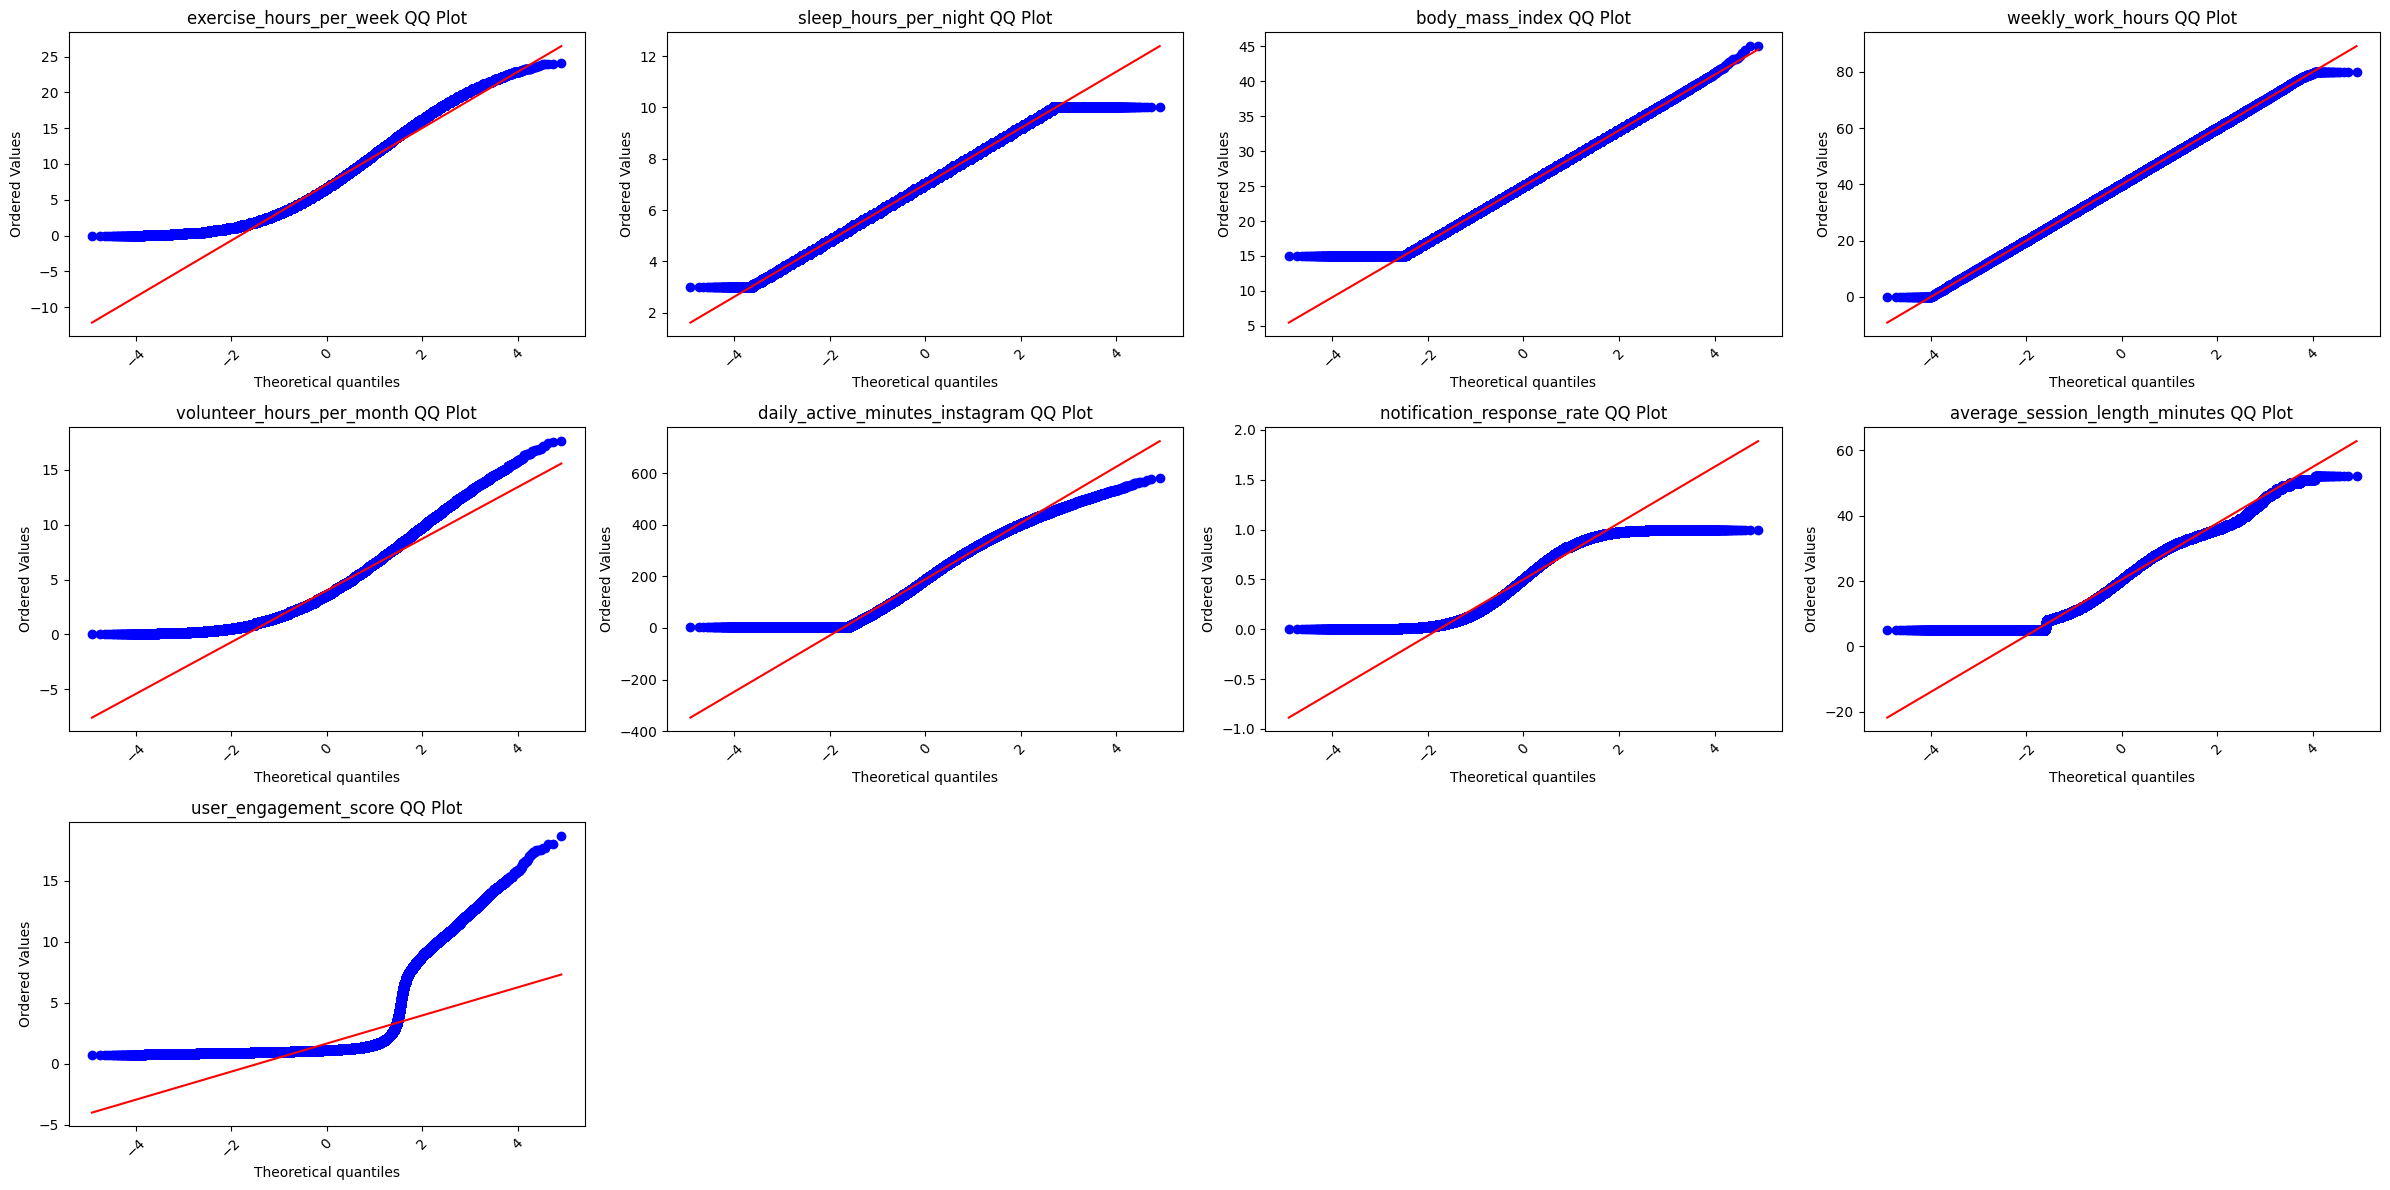

In [24]:
# Q-Q plot of continuous numerical features
n = len(continuous_cols)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    stats.probplot(
        df[col].dropna(),
        plot=axes[i]
    )

    axes[i].set_title(f'{col} QQ Plot')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Outliers Analysis

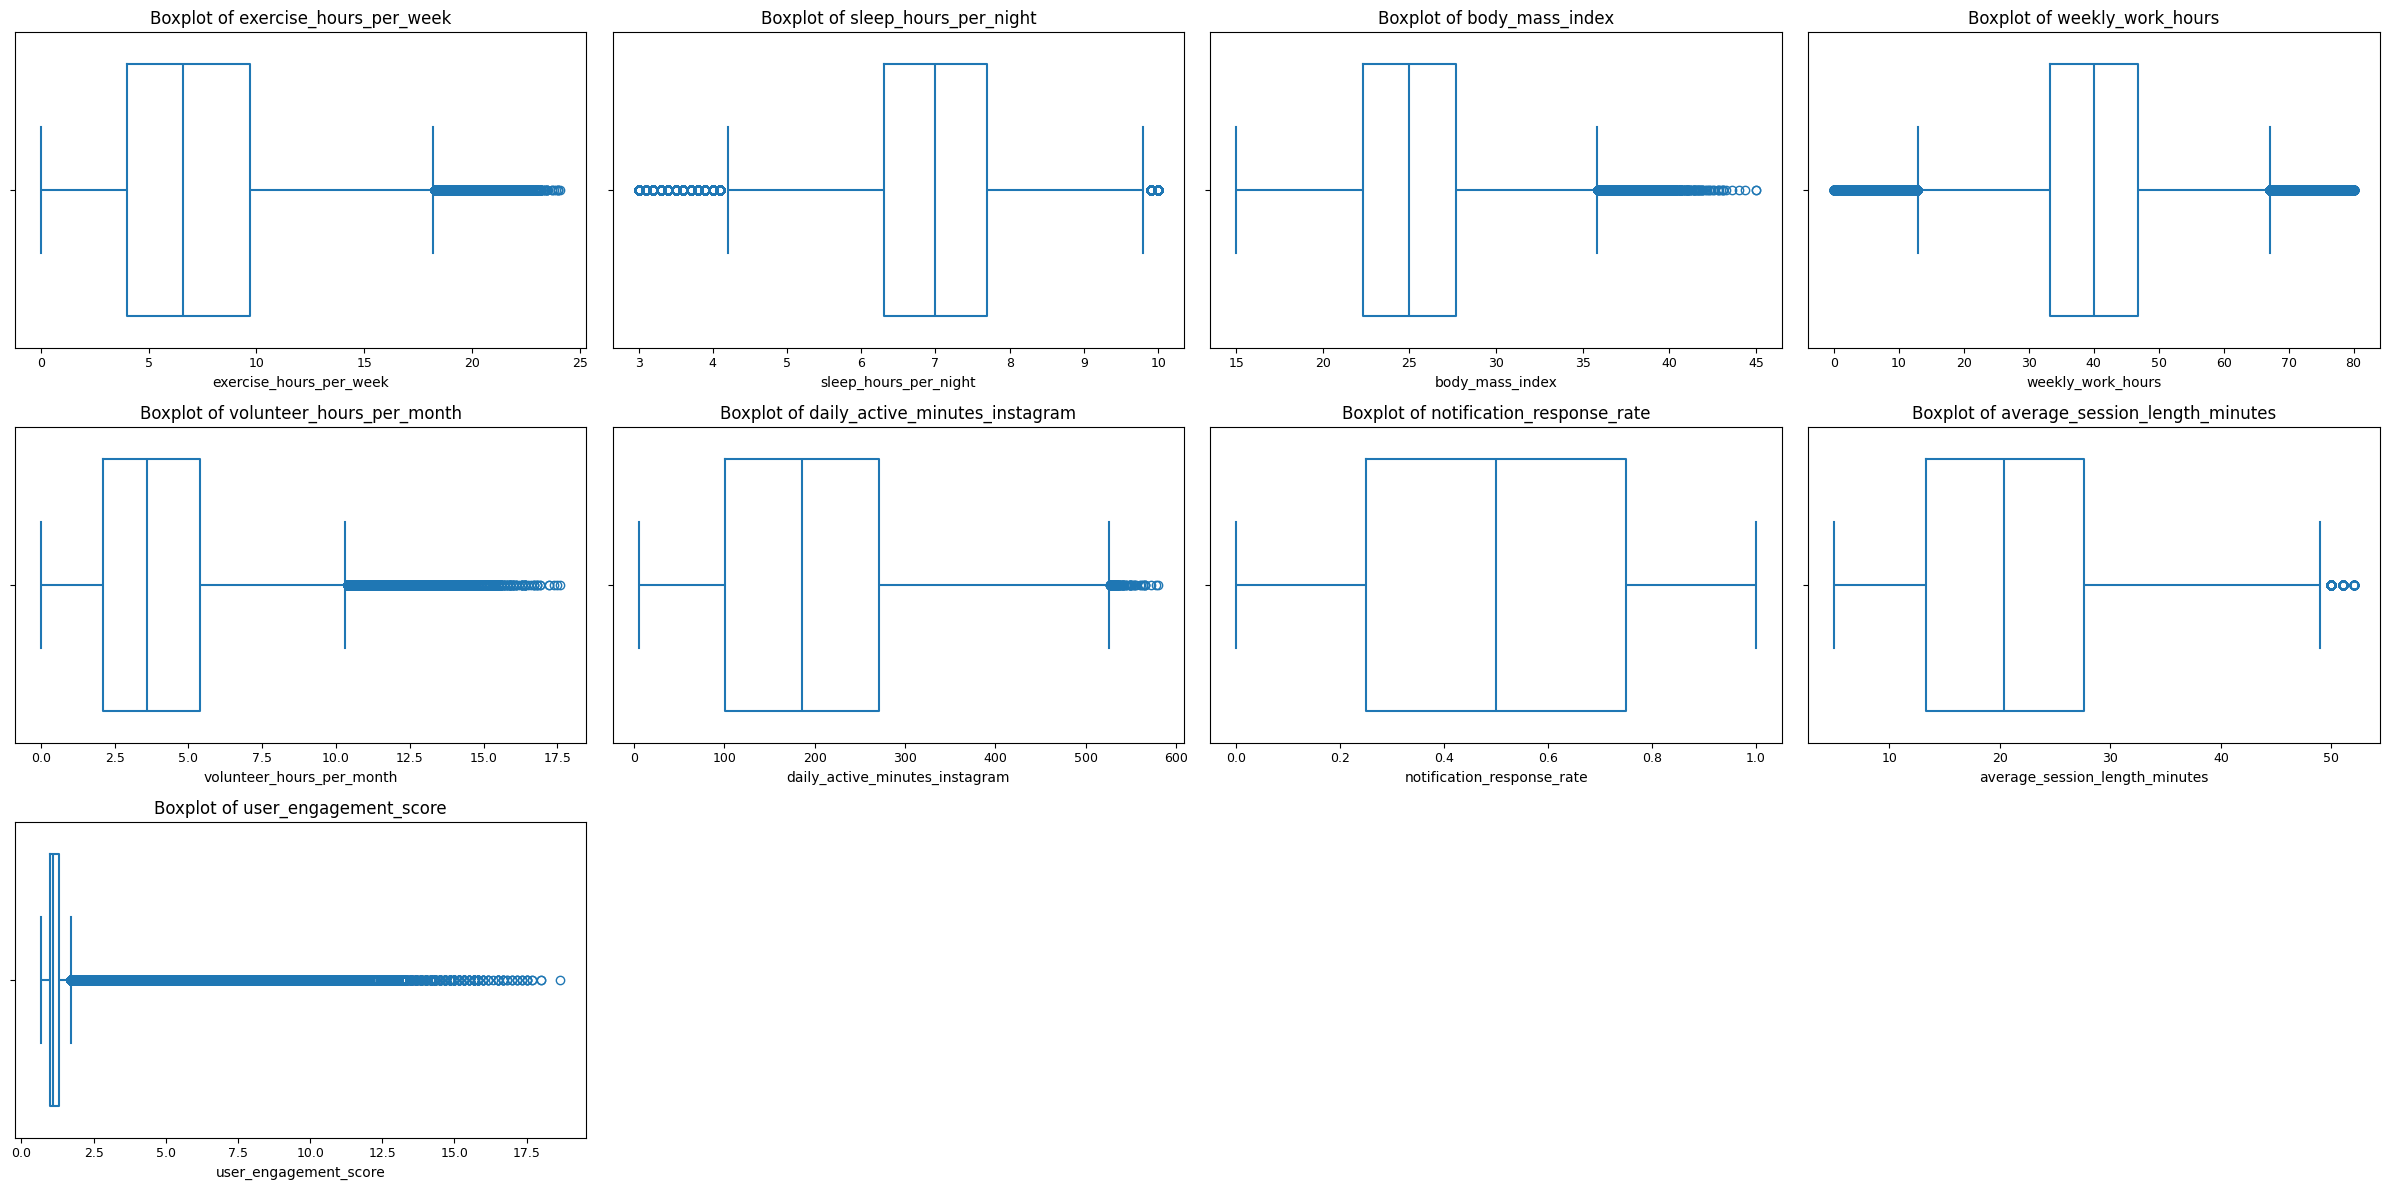

In [25]:
# Box-Plot of Continuous numerical features 
n = len(continuous_cols)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(
        x=df[col],
        fill=False,
        ax=axes[i]
    )

    # Title and axis formatting
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=9)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

📌 What is IQR?

The IQR (Interquartile Range) method helps me identify outliers by measuring how spread out the middle 50% of the data is. I first calculate the first quartile (Q1) and the third quartile (Q3), then compute the IQR as the difference between them. Any data point that falls far below or above this range is considered a potential outlier.

In [26]:
def count_outliers(df, continuous_cols):
    """
    Count lower, upper, and total outliers for each continuous feature using the IQR method.

    This function calculates outliers based on the Interquartile Range (IQR):
    values below (Q1 - 1.5 × IQR) are considered lower outliers and
    values above (Q3 + 1.5 × IQR) are considered upper outliers.

    Parameters
    ----------
    df : pandas.DataFrame
        The input dataframe containing the data.
    continuous_cols : list of str
        List of column names representing continuous numerical features.

    Returns
    -------
    pandas.DataFrame
        A summary dataframe with the following columns:
        - Feature: Name of the column
        - Lower Outliers: Number of lower outliers
        - Upper Outliers: Number of upper outliers
        - Total Outliers: Total number of outliers
    """

    results = []

    for col in continuous_cols:
        q1 = np.percentile(df[col].dropna(), 25)
        q3 = np.percentile(df[col].dropna(), 75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        lower_outliers = df[col] < lower_limit
        upper_outliers = df[col] > upper_limit

        n_lower = lower_outliers.sum()
        n_upper = upper_outliers.sum()
        total = n_lower + n_upper

        results.append({
            "Feature": col,
            "Lower Outliers": n_lower,
            "Upper Outliers": n_upper,
            "Total Outliers": total
        })

    return pd.DataFrame(results)

In [27]:
count_outliers(df, continuous_cols)

,Feature,Lower Outliers,Upper Outliers,Total Outliers
0,exercise_hours_per_week,0,10387,10387
1,sleep_hours_per_night,7240,7595,14835
2,body_mass_index,0,5071,5071
3,weekly_work_hours,5042,5135,10177
4,volunteer_hours_per_month,0,23567,23567
5,daily_active_minutes_instagram,0,94,94
6,notification_response_rate,0,0,0
7,average_session_length_minutes,0,341,341
8,user_engagement_score,0,202645,202645


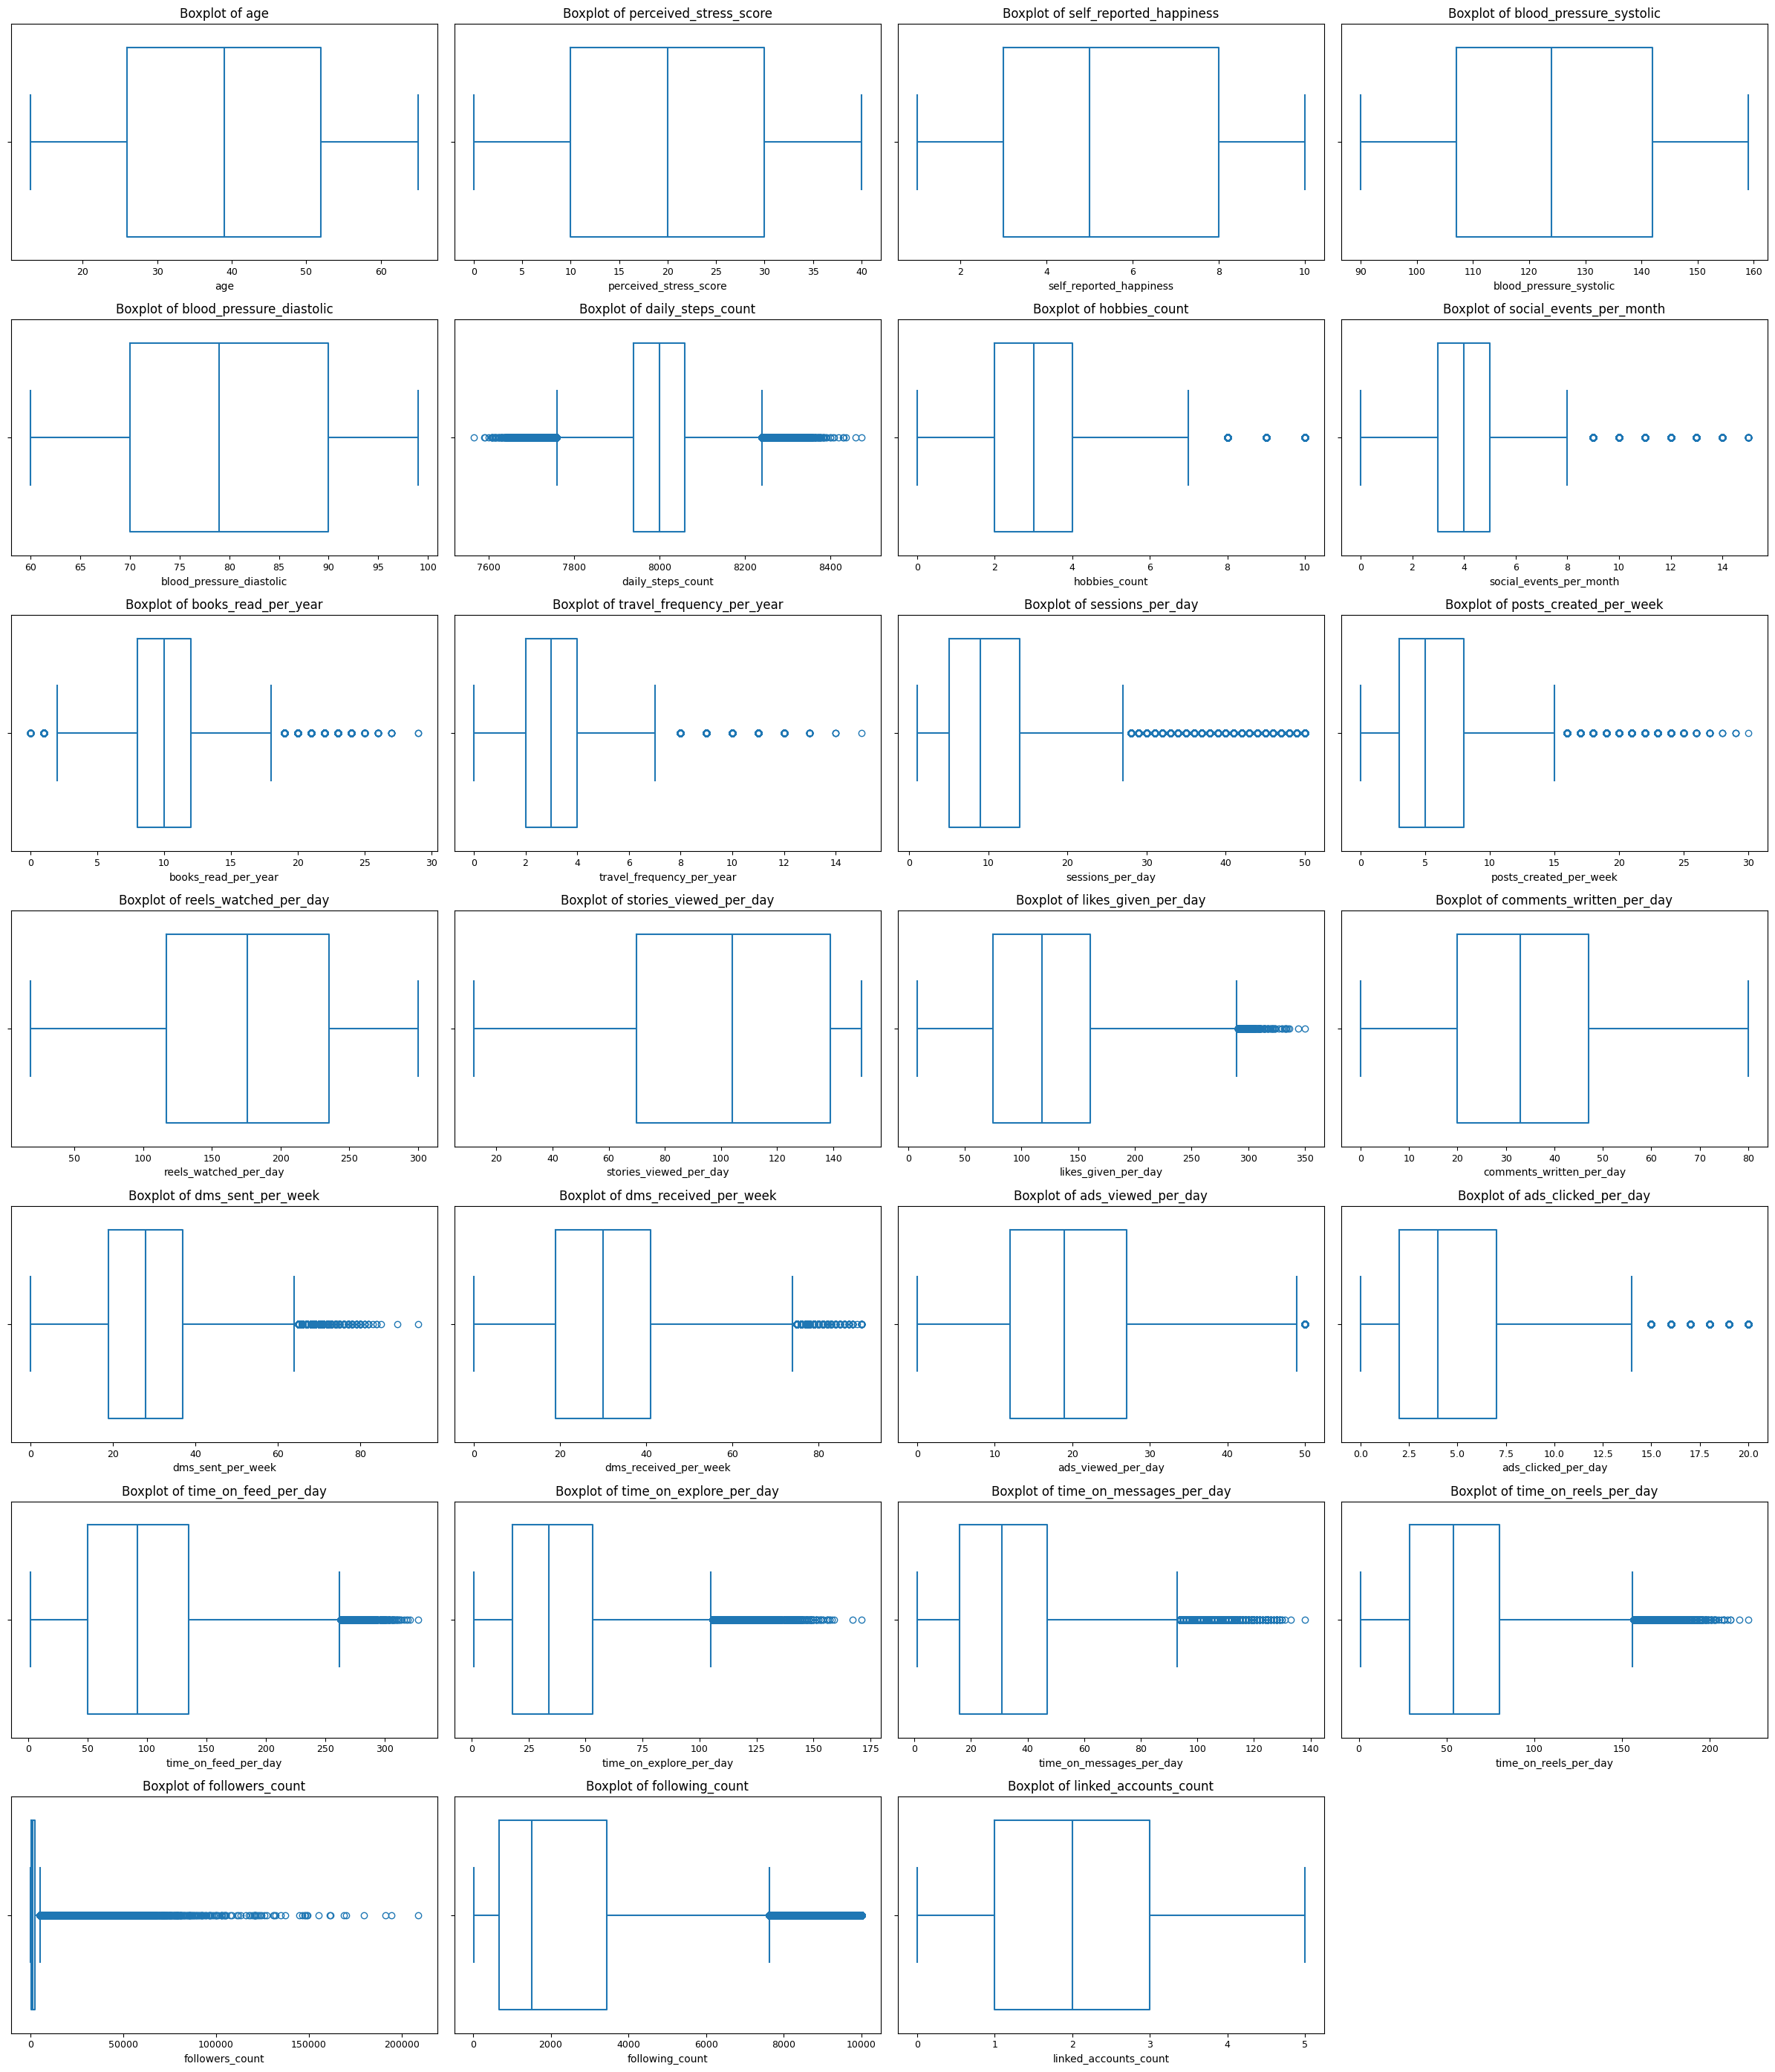

In [28]:
# Box-Plot of Discrete numerical features 
n = len(discrete_cols)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    sns.boxplot(
        x=df[col],
        fill=False,
        ax=axes[i]
    )

    # Title and axis formatting
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=9)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [29]:
count_outliers(df, discrete_cols)

,Feature,Lower Outliers,Upper Outliers,Total Outliers
0,age,0,0,0
1,perceived_stress_score,0,0,0
2,self_reported_happiness,0,0,0
3,blood_pressure_systolic,0,0,0
4,blood_pressure_diastolic,0,0,0
5,daily_steps_count,5289,5777,11066
6,hobbies_count,0,18403,18403
7,social_events_per_month,0,33207,33207
8,books_read_per_year,761,10950,11711
9,travel_frequency_per_year,0,18526,18526


## Datetime Features Analysis

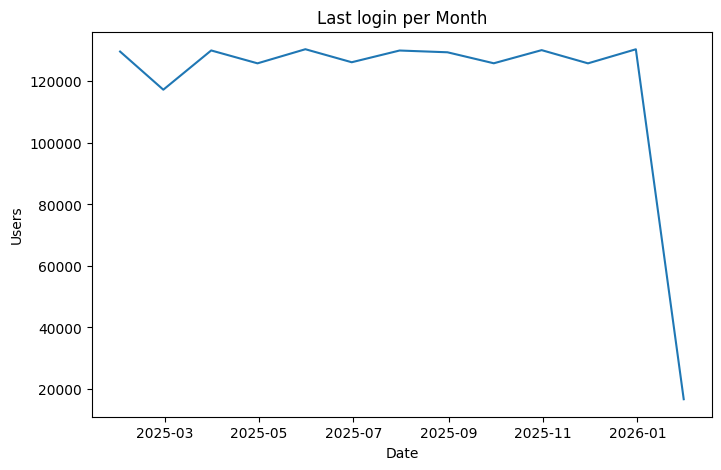

In [30]:
# Aggregate order timestamps into monthly counts and visualize the time-series trend in order volume

monthly_counts = df.set_index('last_login_date').resample('ME')['user_id'].count()

plt.figure(figsize=(8,5))
plt.plot(monthly_counts.index, monthly_counts.values)

plt.title('Last login per Month')
plt.xlabel('Date')
plt.ylabel('Users')

plt.show()

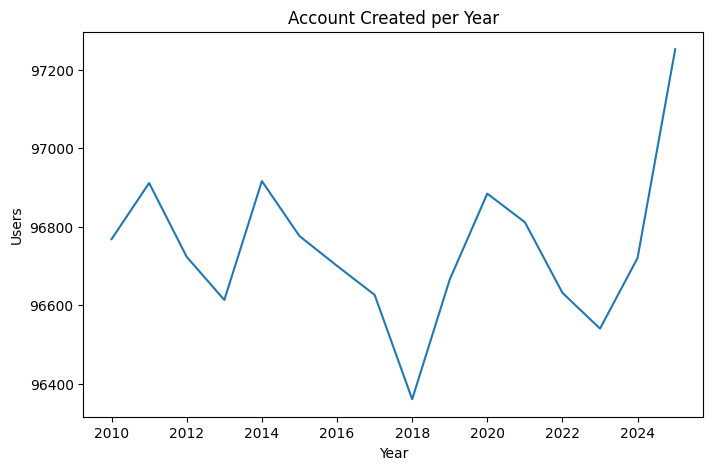

In [31]:
yearly_counts = df.set_index('account_creation_year').resample('YS')['user_id'].count()

plt.figure(figsize=(8,5))
plt.plot(yearly_counts.index, yearly_counts.values)

plt.title('Account Created per Year')
plt.xlabel('Year')
plt.ylabel('Users')

plt.show()

📌 **Observation**

The number of accounts created per year remains relatively stable over time, with only minor fluctuations. There is no strong long-term upward or downward trend, suggesting that user growth is fairly consistent across years. However, a noticeable spike appears in the most recent year, which may indicate a sudden increase in adoption or could be influenced by how the dataset was generated.

# Bi-Variate Analysis
---

In [32]:
df.loc[:, cat_cols]

,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,uses_premium_features,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,subscription_status
0,Female,India,Rural,High,Retired,Bachelor’s,Single,No,Good,No,Rarely,No,Mixed,Tech,Private,Yes,No,Free
1,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,Very poor,No,Rarely,No,Photos,Fashion,Public,No,No,Free
2,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,No,Good,No,Rarely,No,Mixed,Other,Public,Yes,Yes,Free
3,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,Never,No,Stories,Tech,Private,No,No,Free
4,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,No,Average,No,Never,Yes,Videos,Food,Public,Yes,No,Free
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,Female,United States,Suburban,High,Full-time employed,Master’s,Widowed,No,Good,No,Weekly,No,Videos,Other,Friends only,Yes,Yes,Free
1547892,Male,United States,Urban,Lower-middle,Full-time employed,Master’s,Divorced,No,Excellent,No,Never,No,Photos,Art,Private,No,No,Premium
1547893,Male,Canada,Urban,Low,Full-time employed,Master’s,Single,No,Average,No,Weekly,No,Live,Other,Private,Yes,Yes,Free
1547894,Female,Other,Urban,Low,Student,Bachelor’s,Single,No,Poor,No,Never,No,Live,Tech,Private,Yes,No,Free


## Categorical vs Categorical

**alcohol_frequency vs gender**

This contingency table explores the relationship between **alcohol consumption** frequency and **gender**. It shows how individuals are distributed across different alcohol consumption categories for each gender. By analyzing this table, I aim to identify patterns or differences in drinking behavior between genders, which may reveal trends in lifestyle habits or preferences within the dataset.

In [33]:
pd.crosstab(
    index=df['alcohol_frequency'],
    columns=df['gender'],
    margins=True,
    normalize=False
)

gender,Female,Male,Non-binary,Prefer not to say,All
alcohol_frequency,,,,,
Daily,36685,37302,2238,773,76998
Never,222721,222965,13679,4682,464047
Rarely,260152,259873,16322,5431,541778
Several times a week,74441,74370,4628,1599,155038
Weekly,148848,148659,9329,3199,310035
All,742847,743169,46196,15684,1547896


📌 **Observation**

* Near-perfect balance between male and female counts: Across every alcohol category, male and female counts are almost identical. This level of symmetry is unusual in real-world behavioral data and suggests the dataset may be artificially balanced.

* Stable proportional representation of minority genders: The share of non-binary and prefer not to say categories remains very consistent across all drinking frequencies, indicating that alcohol behavior does not appear to vary meaningfully by gender in this dataset.

* Alcohol frequency appears gender-neutral: There is no visible skew where one gender dominates higher or lower drinking frequencies. This suggests that alcohol consumption patterns are statistically uniform across genders.

**subscription status vs country**

This contingency table explores the relationship between **subscription status** and **country**. It shows how customers are distributed across subscription categories within each country. By examining this table, we aim to identify geographic patterns or differences in subscription behavior, which may indicate variations in user engagement, market penetration, or regional preferences.

In [34]:
pd.crosstab(
    index=df['subscription_status'],
    columns=df['country'],
    margins=True,
    normalize=False
)

country,Australia,Brazil,Canada,Germany,India,Japan,Other,South Korea,United Kingdom,United States,All
subscription_status,,,,,,,,,,,
Business,9305,18555,10682,7835,28049,6226,15551,7858,12420,38791,155272
Free,69340,139611,81552,58007,208588,46455,115905,58341,92494,289834,1160127
Premium,13877,28092,16350,11487,41705,9318,23116,11851,18497,58204,232497
All,92522,186258,108584,77329,278342,61999,154572,78050,123411,386829,1547896


📌 **Observation**

* User concentration: The majority of users come from the United States and India, making them the largest and most important markets in the dataset.

* Dominance of Free plan: In every country, the Free subscription heavily dominates, showing that most users are not converting to paid plans.

* Paid subscription pattern: Countries with larger user bases also tend to have higher Premium and Business subscriptions, suggesting stronger monetization potential.

* Global consistency: The subscription distribution pattern is fairly consistent across countries, indicating similar user behavior worldwide.

* International reach: The “Other” countries category contributes a significant share of total users, highlighting broad global adoption.

alcohol_frequency vs smoking

This contingency table explores the relationship between alcohol consumption frequency and smoking status. It shows how individuals are distributed across different alcohol consumption categories for each smoking group. By analyzing this table, I aim to identify patterns or associations between drinking and smoking habits, which may help reveal lifestyle behavior trends present in the dataset.

In [35]:
pd.crosstab(
    index=df['alcohol_frequency'],
    columns=df['smoking'],
    margins=True,
    normalize=False
)

smoking,Former,No,Yes,All
alcohol_frequency,,,,
Daily,7830,57505,11663,76998
Never,46211,347705,70131,464047
Rarely,54223,406209,81346,541778
Several times a week,15642,116089,23307,155038
Weekly,30878,232671,46486,310035
All,154784,1160179,232933,1547896


📌 **Observation**

* Non-smokers dominate across all alcohol categories: In every drinking frequency group, the majority of individuals are non-smokers, suggesting that smoking is less common overall in the dataset.

* Higher alcohol frequency aligns with higher smoking presence: Categories like Daily and Several times a week show a relatively larger proportion of smokers compared to the Never drinking group, indicating a possible association between frequent alcohol use and smoking habits.

* “Rarely” and “Never” drinking groups are the largest: Most individuals fall into lower alcohol consumption categories, which suggests that heavy or frequent drinking is less common in this population.

* Former smokers form a meaningful segment: The number of former smokers is substantial across all alcohol categories, which may indicate behavioral transitions or lifestyle changes over time.

* Potential lifestyle correlation: The overall pattern suggests a gradual increase in smoking presence as alcohol consumption becomes more frequent, hinting at a behavioral link between the two habits.


In [36]:
# Chi-square test of independence between alcohol_frequency and smoking

# Create contingency table (observed frequencies)
ct = pd.crosstab(df['alcohol_frequency'], df['smoking'])

print("Contingency Table (Observed Frequencies):")
print(ct)
print("="*60)

# Perform Chi-square test of independence
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")
print("="*60)

# Expected frequencies under independence assumption
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print("Expected Frequencies (if variables were independent):")
print(expected_df)
print("="*60)

# Hypothesis decision
alpha = 0.05

print("Hypothesis Test Conclusion:")
print("H0: alcohol_frequency and smoking are independent")
print("H1: alcohol_frequency and smoking are associated")

if p < alpha:
    print("\nReject H0 → There is a statistically significant association.")
else:
    print("\nFail to reject H0 → No significant association detected.")

Contingency Table (Observed Frequencies):
smoking               Former      No    Yes
alcohol_frequency                          
Daily                   7830   57505  11663
Never                  46211  347705  70131
Rarely                 54223  406209  81346
Several times a week   15642  116089  23307
Weekly                 30878  232671  46486
Chi-square statistic: 8.9214
p-value: 0.348971
Degrees of freedom: 8
Expected Frequencies (if variables were independent):
smoking                     Former             No           Yes
alcohol_frequency                                              
Daily                  7699.521436   57711.540467  11586.938098
Never                 46403.021164  347812.504466  69831.474370
Rarely                54175.839948  406073.443088  81528.716964
Several times a week  15503.239101  116204.080766  23330.680132
Weekly                31002.378351  232377.431213  46655.190436
Hypothesis Test Conclusion:
H0: alcohol_frequency and smoking are independent
H

Let’s examine how alcohol consumption behavior changes across different income groups.

In [37]:
pd.crosstab(
    index=df['gender'],
    columns=df['preferred_content_theme'],
    margins=True,
    normalize=False
)

preferred_content_theme,Art,Fashion,Fitness,Food,Music,Other,Tech,Travel,All
gender,,,,,,,,,
Female,92732,92936,93366,92924,93019,93104,92695,92071,742847
Male,92616,92885,93323,92856,92730,92761,93200,92798,743169
Non-binary,5653,5687,5832,5817,5733,5822,5858,5794,46196
Prefer not to say,1990,1956,2022,1986,1982,1922,1959,1867,15684
All,192991,193464,194543,193583,193464,193609,193712,192530,1547896


📌 **Observation**

In practice, we would expect at least some natural preference differences — for example, fashion and lifestyle content is often more popular among female audiences, while technology-related content tends to attract relatively higher engagement from male audiences. Similarly, interests like fitness, travel, or music usually show mild demographic skews. The absence of any noticeable variation suggests that user preferences have been artificially balanced, which is another strong indication that this dataset is synthetic rather than organically collected.

## Categorical vs Numerical

In [38]:
df.groupby('employment_status')['daily_active_minutes_instagram'].mean().to_frame(name='avg_spent_time')

,avg_spent_time
employment_status,
Freelancer,188.166173
Full-time employed,188.156383
Part-time,189.050467
Retired,187.447097
Student,188.210388
Unemployed,188.258105


📌 **Observation**

The average daily active minutes on Instagram are nearly identical across all employment categories. This uniformity is unrealistic for real-world user behavior, where different employment statuses would typically lead to noticeable differences in social media usage patterns. **For examples** - students or unemployed individuals would typically spend more time on Instagram, while full-time employed or retired individuals might show comparatively lower usage due to time constraints and lifestyle differences.

In [39]:
df.groupby('diet_quality')[['blood_pressure_systolic', 'blood_pressure_diastolic']].mean()

,blood_pressure_systolic,blood_pressure_diastolic
diet_quality,,
Average,124.527767,79.484632
Excellent,124.502246,79.493062
Good,124.433537,79.493555
Poor,124.487610,79.517569
Very poor,124.507847,79.542720


📌 **Observation**

The average systolic and diastolic blood pressure values are nearly identical across all diet quality categories. This lack of variation is unrealistic for real-world health data, where diet quality would typically show at least some measurable association with blood pressure. The uniform pattern strongly suggests that this aspect of the dataset may be synthetic or artificially generated.

In [40]:
pd.crosstab(
    index=df['alcohol_frequency'],
    columns=df['income_level'],
    margins=True,
    normalize=False
)

income_level,High,Low,Lower-middle,Middle,Upper-middle,All
alcohol_frequency,,,,,,
Daily,7582,15336,19388,23103,11589,76998
Never,46617,92532,115993,139361,69544,464047
Rarely,54074,108687,135304,163075,80638,541778
Several times a week,15382,31377,38703,46347,23229,155038
Weekly,30906,61804,77427,93151,46747,310035
All,154561,309736,386815,465037,231747,1547896


📌 **Observation**

* Alcohol consumption scales with income in a stable proportion: Across all drinking frequencies, the relative distribution of income groups remains surprisingly consistent, suggesting that alcohol habits are not strongly skewed toward any single income class.

* Middle-income groups drive most behavioral patterns: Subtle shifts in alcohol frequency are primarily influenced by the large middle and lower-middle income segments, meaning overall trends in drinking behavior are likely shaped more by population structure than by extreme income groups.

* High-income representation is proportionally steady in frequent drinking: The share of high-income individuals does not spike dramatically in higher-frequency drinking categories, which challenges the assumption that frequent alcohol consumption is concentrated in wealthier groups.

* No sharp income-based polarization is visible: Instead of seeing a strong divide (e.g., only low or high income dominating certain categories), the pattern suggests alcohol consumption is relatively income-neutral in this dataset.

In [41]:
pd.crosstab(
    index=df['privacy_setting_level'],
    columns=df['gender'],
    margins=True,
    normalize=False
)

gender,Female,Male,Non-binary,Prefer not to say,All
privacy_setting_level,,,,,
Friends only,247427,247633,15561,5203,515824
Private,247463,247664,15372,5338,515837
Public,247957,247872,15263,5143,516235
All,742847,743169,46196,15684,1547896


This analysis helps me understand how account creation trends change over time for different genders. By resampling the data yearly and counting accounts per gender, I can observe whether certain genders are growing faster, remaining stable, or declining over time.

In [42]:
yearly_gender = (
    df.set_index('account_creation_year')
      .groupby('gender')
      .resample('YS')
      .size()
      .unstack(0)
)

yearly_gender

gender,Female,Male,Non-binary,Prefer not to say
account_creation_year,,,,
2010-01-01,46099,46944,2780,945
2011-01-01,46470,46676,2811,954
2012-01-01,46367,46462,2888,1006
2013-01-01,46309,46476,2853,975
2014-01-01,46669,46316,2937,994
2015-01-01,46281,46617,2841,1037
2016-01-01,46356,46495,2912,937
2017-01-01,46590,46179,2941,916
2018-01-01,46375,46100,2910,975


In [43]:
yearly_country = (
    df.set_index('account_creation_year')
      .groupby('country')
      .resample('YS')
      .size()
      .unstack(0)
)

yearly_country

country,Australia,Brazil,Canada,Germany,India,Japan,Other,South Korea,United Kingdom,United States
account_creation_year,,,,,,,,,,
2010-01-01,5745,11658,6864,4747,17360,3909,9607,4847,7629,24402
2011-01-01,5709,11676,6855,4791,17404,3740,9759,5026,7732,24219
2012-01-01,5807,11715,6700,4700,17467,3963,9661,4796,7534,24380
2013-01-01,5726,11650,6698,4980,17332,3840,9487,4865,7699,24336
2014-01-01,5742,11685,6745,4951,17494,3874,9672,4782,7832,24139
2015-01-01,5737,11647,6703,4967,17390,4014,9589,4822,7753,24154
2016-01-01,5829,11375,6787,4982,17281,3866,9729,4863,7811,24177
2017-01-01,5852,11821,6796,4737,17447,3829,9597,4732,7512,24303
2018-01-01,5870,11669,6645,4887,17449,3863,9593,4837,7651,23896


**📌 Observation**

The majority of yearly user logins come from the United States and India.

In [44]:
df.set_index('account_creation_year').groupby('urban_rural').resample('YS')['user_id'].count().unstack(0)

urban_rural,Rural,Suburban,Urban
account_creation_year,,,
2010-01-01,14486,28944,53338
2011-01-01,14640,29088,53183
2012-01-01,14384,29053,53286
2013-01-01,14436,29211,52966
2014-01-01,14607,29151,53158
2015-01-01,14576,29092,53108
2016-01-01,14492,28949,53259
2017-01-01,14777,28960,52889
2018-01-01,14571,28703,53086


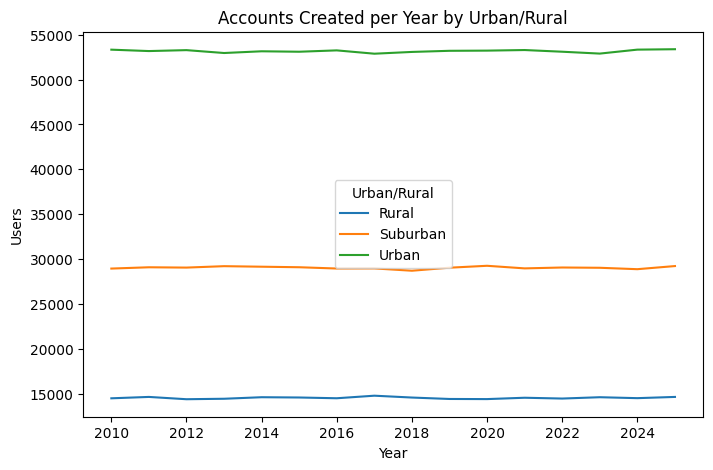

In [45]:
yearly_urban = (
    df.set_index('account_creation_year')
      .groupby('urban_rural')
      .resample('YS')['user_id']
      .count()
      .unstack(0)
)

plt.figure(figsize=(8, 5))

for col in yearly_urban.columns:
    plt.plot(yearly_urban.index, yearly_urban[col], label=col)

plt.title('Accounts Created per Year by Urban/Rural')
plt.xlabel('Year')
plt.ylabel('Users')
plt.legend(title='Urban/Rural')

plt.show()

📌 **Observation**

Account creation trends remain relatively stable over time across urban, suburban, and rural areas, with no major spikes or drops. Urban areas consistently contribute the highest number of new accounts each year, followed by suburban and then rural regions. This observation is plausible, as urban populations are often more engaged with social media platforms.

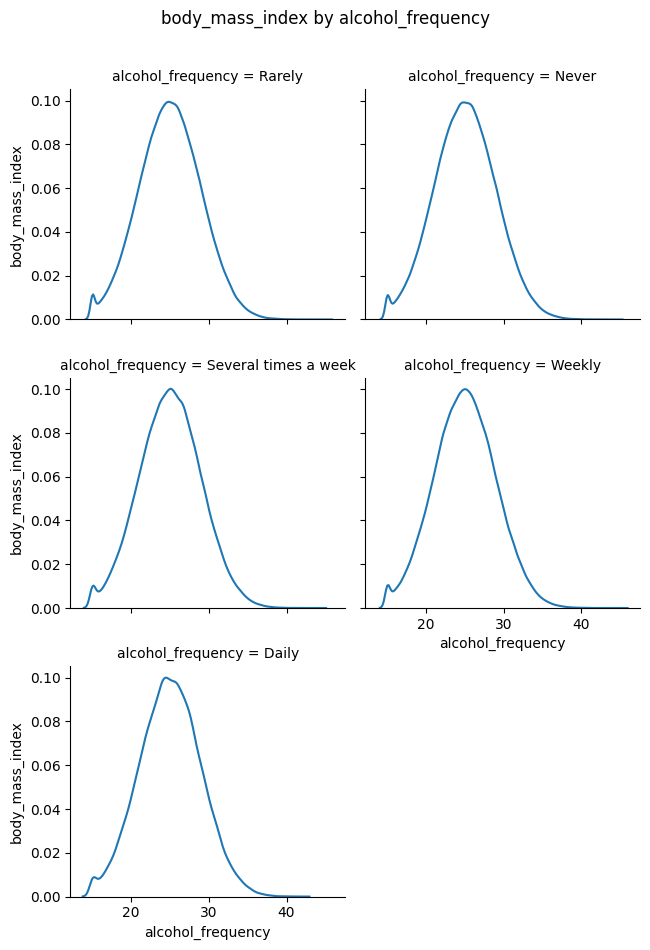

In [46]:
# Create FacetGrid
g = sns.FacetGrid(
    df,
    col="alcohol_frequency",          # split plots by column category
    row=None,
    col_wrap=2,
    height=3,
    aspect=1.1
)

# Map a plot onto the grid
g.map(sns.kdeplot, "body_mass_index")

g.fig.suptitle("body_mass_index by alcohol_frequency", y=1.05)
g.set_axis_labels("alcohol_frequency", "body_mass_index")

plt.show()

📌 **Observation**

The KDE plots show nearly identical BMI distributions across all alcohol frequency categories. In a real-world scenario, I would expect some variation — for example, higher alcohol consumption might be associated with gradual changes in BMI. The absence of noticeable differences across groups suggests the dataset may not reflect natural behavioral variation and could be synthetic or artificially generated.

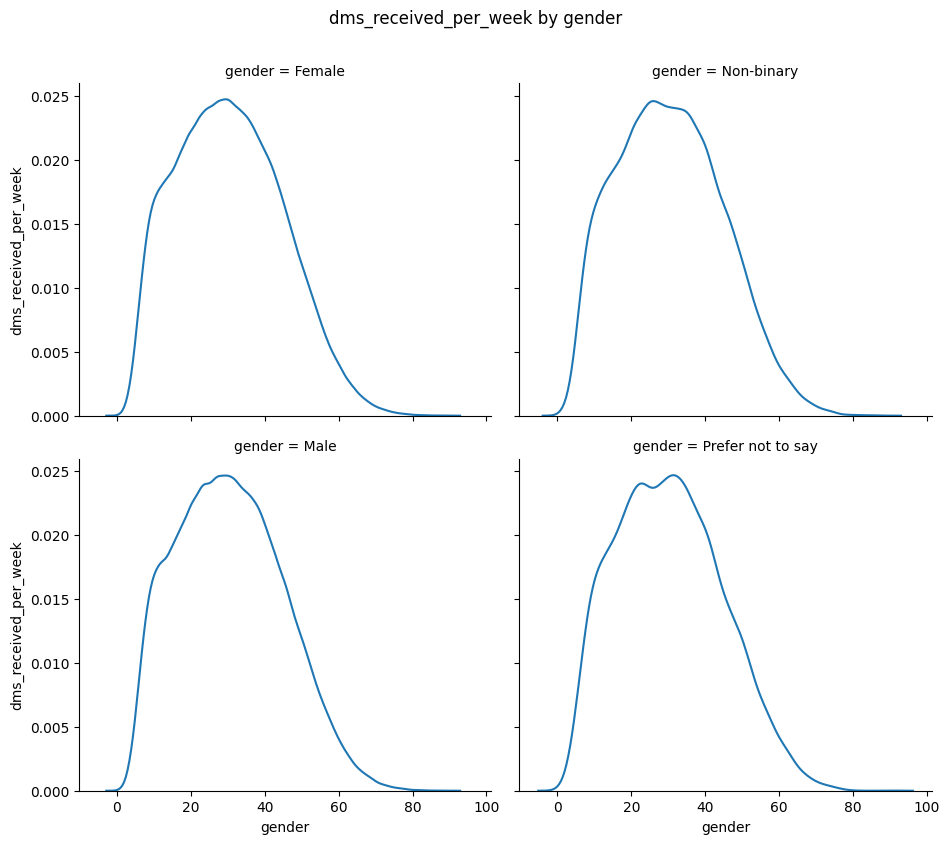

In [47]:
# Create FacetGrid
g = sns.FacetGrid(
    df,
    col="gender",          # split plots by column category
    row=None,
    col_wrap=2,
    height=4,
    aspect=1.2
)

# Map a plot onto the grid
g.map(sns.kdeplot, "dms_received_per_week")

g.fig.suptitle("dms_received_per_week by gender", y=1.05)
g.set_axis_labels("gender", "dms_received_per_week")

plt.show()

📌 **Observation**

Each gender appears to receive a very similar number of DMs per week. This uniform pattern is somewhat unusual and may be misleading, this again suggests the dataset is synthetic or artificially balanced

# **Final Verdict**

After completing a full exploratory data analysis — from univariate to bivariate — I found this dataset to be well-structured, large in scale, and enjoyable to work with from a technical perspective. It provides a wide variety of features related to user behavior, demographics, and activity patterns, which makes it a good resource for practicing EDA techniques and visualization workflows.

However, during the analysis, several patterns repeatedly appeared that are unlikely in real-world social media data. Many variables show near-uniform or artificially balanced distributions across categories, and multiple relationships that would normally exhibit natural variation (such as behavioral or health-related features across demographic groups) remain almost identical. This consistency reduces the ability to uncover meaningful or surprising insights, since real social datasets typically contain noise, imbalance, and stronger behavioral differences.

Because of these observations, the dataset appears to be synthetic or heavily simulated. While this limits its usefulness for drawing real-world conclusions or discovering deep behavioral insights, it still serves as a solid practice dataset for learning exploratory data analysis, visualization techniques, and feature interpretation. Overall, it is a valuable educational resource, but not ideal for extracting realistic social media trends or actionable findings.


# Next part in 5 upvotes😇.....